In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pycaret.classification import setup, compare_models,evaluate_model, plot_model, create_model, tune_model, finalize_model, predict_model, save_model
import optuna


# Innits


In [2]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])


data_36 = data_24_25_test[data_24_25_test['event'] == 36]
data_37 = data_24_25_test[data_24_25_test['event'] == 37]
data_38 = data_24_25_test[data_24_25_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [3]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Clean Sheets


In [4]:
cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


clean_sheets
0    1231
1     381
Name: count, dtype: int64


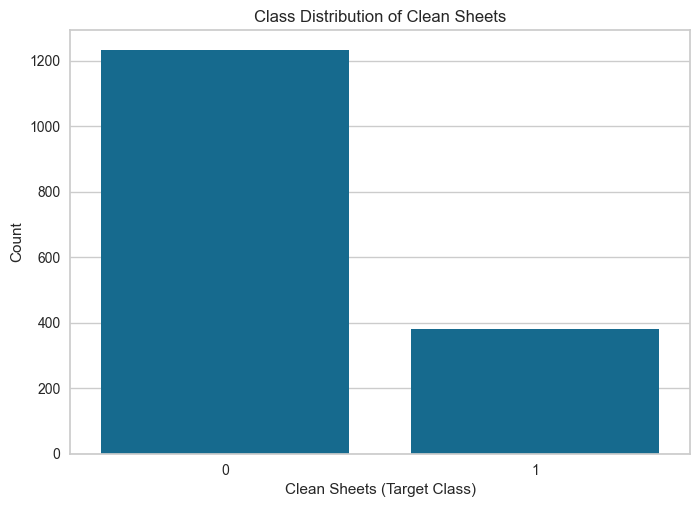

In [5]:
g_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_cs_data = g_cs_data[cs_features]
g_cs_data_tar = g_cs_data_tar[cs_features]

g_cs_data.reset_index(drop=True, inplace=True)
g_cs_data.reset_index(drop=True, inplace=True)

g_cs_data.drop(columns=['position'], inplace=True)
g_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(g_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=g_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [6]:
g_cs_base_model = setup(data=g_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        # remove_multicollinearity=True,
                        normalize=True,
                        feature_selection=True,
                        # polynomial_features=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 816, number of negative: 816
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002467 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11794
[LightGBM] [Info] Number of data points in the train set: 1632, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1612, 73)"
4,Transformed data shape,"(2116, 15)"
5,Transformed train set shape,"(1632, 15)"
6,Transformed test set shape,"(484, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [7]:
best_base_g_cs = g_cs_base_model.compare_models(sort='AUC')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,20:11:40
Status,. . . . . . . . . . . . . . . . . .,Loading Estimator
Estimator,. . . . . . . . . . . . . . . . . .,Logistic Regression


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.5700,0.5820,0.5459,0.2888,0.3769,0.0964,0.1062,1.5300
lr,Logistic Regression,0.5700,0.5814,0.5496,0.2891,0.3782,0.0977,0.1082,15.3600
lda,Linear Discriminant Analysis,0.5718,0.5811,0.5496,0.2908,0.3794,0.1001,0.1104,2.4890
et,Extra Trees Classifier,0.6888,0.5642,0.1765,0.2556,0.2053,0.0245,0.0245,6.1210
xgboost,Extreme Gradient Boosting,0.6862,0.5627,0.2063,0.2842,0.2327,0.0455,0.0479,11.2300
svm,SVM - Linear Kernel,0.5639,0.5608,0.4860,0.2695,0.3420,0.0583,0.0655,1.6680
gbc,Gradient Boosting Classifier,0.6809,0.5572,0.1990,0.2667,0.2237,0.0318,0.0327,2.8210
rf,Random Forest Classifier,0.6729,0.5562,0.1574,0.2260,0.1828,-0.0115,-0.0114,1.6600
lightgbm,Light Gradient Boosting Machine,0.6871,0.5473,0.1501,0.2381,0.1798,0.0027,0.0029,4.0260
qda,Quadratic Discriminant Analysis,0.5444,0.5426,0.5164,0.2635,0.3483,0.0519,0.0591,1.3590


In [8]:
evaluate_model(best_base_g_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [9]:
tune_model_gk_cs = tune_model(best_base_g_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5310,0.5133,0.4231,0.2245,0.2933,-0.0105,-0.0116
1,0.6903,0.6357,0.6667,0.4091,0.5070,0.2996,0.3186
2,0.5133,0.5896,0.5556,0.2586,0.3529,0.0399,0.0474
3,0.6018,0.5728,0.5556,0.3125,0.4000,0.1356,0.1482
4,0.6018,0.6124,0.5185,0.3043,0.3836,0.1180,0.1271
5,0.4779,0.4871,0.5556,0.2419,0.3371,0.0063,0.0078
6,0.5575,0.5461,0.5556,0.2830,0.3750,0.0855,0.0972
7,0.6018,0.7127,0.6667,0.3333,0.4444,0.1847,0.2118
8,0.5357,0.5420,0.4231,0.2292,0.2973,-0.0055,-0.0061


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [ ]:
evaluate_model(tune_model_gk_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [11]:
final_best_base_g_cs = finalize_model(tune_model_gk_cs)
save_model(final_best_base_g_cs, './models/gk_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          reg_alpha=0.

## DEF


clean_sheets
0    5131
1    1442
Name: count, dtype: int64


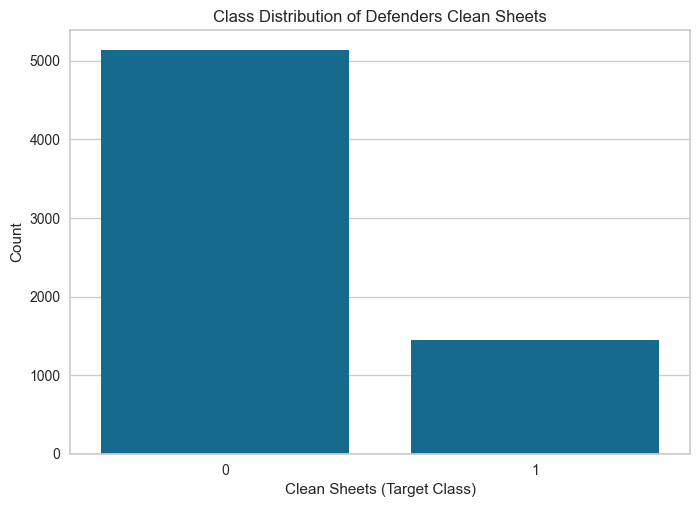

In [12]:
def_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_cs_data = def_cs_data[cs_features]
def_cs_data_tar = def_cs_data_tar[cs_features]

def_cs_data.reset_index(drop=True, inplace=True)
def_cs_data.reset_index(drop=True, inplace=True)

def_cs_data.drop(columns=['position'], inplace=True)
def_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(def_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=def_cs_data)
plt.title('Class Distribution of Defenders Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [13]:
def_cs_base_model = setup(data=def_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 3427, number of negative: 3427
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.183043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14667
[LightGBM] [Info] Number of data points in the train set: 6854, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6573, 73)"
4,Transformed data shape,"(8826, 15)"
5,Transformed train set shape,"(6854, 15)"
6,Transformed test set shape,"(1972, 15)"
7,Numeric features,71
8,Rows with missing values,0.0%
9,Preprocess,True


In [14]:
best_base_def_cs = def_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8572,0.8537,0.5083,0.7639,0.6088,0.5259,0.5432,10.7750
rf,Random Forest Classifier,0.8446,0.8402,0.3884,0.7996,0.5219,0.4424,0.4840,3.2760
xgboost,Extreme Gradient Boosting,0.8233,0.7986,0.3647,0.6850,0.4752,0.3806,0.4084,9.3570
lightgbm,Light Gradient Boosting Machine,0.8148,0.7861,0.2676,0.7082,0.3873,0.3037,0.3543,5.1230
knn,K Neighbors Classifier,0.5979,0.6727,0.6561,0.3070,0.4176,0.1693,0.1977,2.4440
gbc,Gradient Boosting Classifier,0.7805,0.6701,0.0486,0.5272,0.0881,0.0513,0.1021,3.8020
dt,Decision Tree Classifier,0.7477,0.6541,0.4875,0.4333,0.4586,0.2949,0.2959,2.5620
ada,Ada Boost Classifier,0.7342,0.6027,0.1526,0.2953,0.1974,0.0601,0.0652,2.7310
lr,Logistic Regression,0.5673,0.6019,0.5778,0.2721,0.3698,0.1018,0.1181,3.1640
lda,Linear Discriminant Analysis,0.5629,0.6019,0.5738,0.2684,0.3656,0.0952,0.1110,2.2220


In [15]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [16]:
tune_model_def_cs = tune_model(best_base_def_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6139,0.5893,0.3960,0.2548,0.3101,0.0592,0.0620
1,0.6130,0.6027,0.5300,0.2880,0.3732,0.1275,0.1399
2,0.6413,0.6394,0.4257,0.2867,0.3426,0.1087,0.1128
3,0.5935,0.5712,0.4257,0.2500,0.3150,0.0530,0.0568
4,0.5826,0.6405,0.5941,0.2844,0.3846,0.1247,0.1441
5,0.6891,0.6697,0.3960,0.3279,0.3587,0.1560,0.1572
6,0.6043,0.6037,0.3960,0.2484,0.3053,0.0486,0.0512
7,0.6326,0.6278,0.4653,0.2901,0.3574,0.1192,0.1257
8,0.6370,0.6574,0.4455,0.2885,0.3502,0.1140,0.1192


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [17]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [18]:
final_best_base_def_cs = finalize_model(best_base_def_cs)
save_model(final_best_base_def_cs, './models/def_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                               

## MID


clean_sheets
0    5447
1    1629
Name: count, dtype: int64


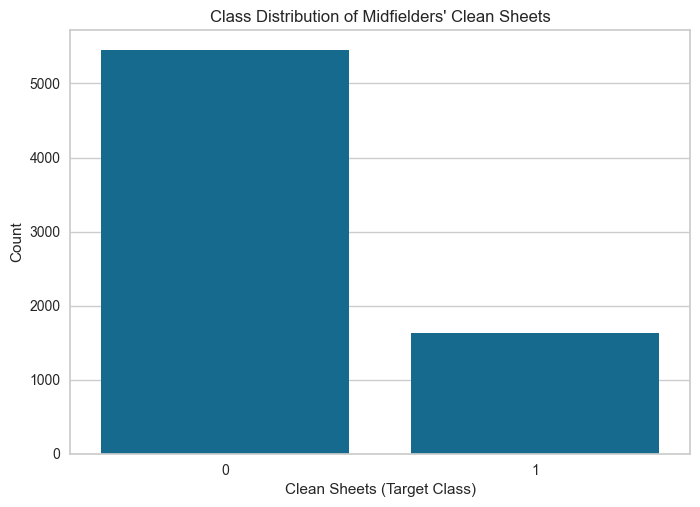

In [19]:
mid_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_cs_data = mid_cs_data[cs_features]
mid_cs_data_tar = mid_cs_data_tar[cs_features]

mid_cs_data.reset_index(drop=True, inplace=True)
mid_cs_data.reset_index(drop=True, inplace=True)

mid_cs_data.drop(columns=['position'], inplace=True)
mid_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(mid_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=mid_cs_data)
plt.title('Class Distribution of Midfielders\' Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [20]:
mid_cs_base_model = setup(data=mid_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 3651, number of negative: 3651
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.351418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15006
[LightGBM] [Info] Number of data points in the train set: 7302, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(7076, 73)"
4,Transformed data shape,"(9425, 15)"
5,Transformed train set shape,"(7302, 15)"
6,Transformed test set shape,"(2123, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [21]:
best_base_mid_cs = mid_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8104,0.7952,0.4000,0.6388,0.4903,0.3821,0.3985,2.1750
rf,Random Forest Classifier,0.8070,0.7694,0.3000,0.6810,0.4145,0.3204,0.3594,2.2740
xgboost,Extreme Gradient Boosting,0.7925,0.7568,0.3289,0.5954,0.4219,0.3079,0.3291,1.8980
lightgbm,Light Gradient Boosting Machine,0.7927,0.7514,0.2351,0.6322,0.3415,0.2486,0.2919,1.8090
gbc,Gradient Boosting Classifier,0.7704,0.6629,0.0728,0.5014,0.1242,0.0730,0.1173,3.5100
knn,K Neighbors Classifier,0.5871,0.6484,0.6377,0.3086,0.4156,0.1529,0.1770,1.4180
lr,Logistic Regression,0.5954,0.6250,0.5789,0.3031,0.3975,0.1364,0.1524,3.7270
ridge,Ridge Classifier,0.5964,0.6248,0.5781,0.3036,0.3976,0.1371,0.1531,1.3450
lda,Linear Discriminant Analysis,0.5966,0.6235,0.5807,0.3043,0.3989,0.1386,0.1548,2.3200
dt,Decision Tree Classifier,0.7036,0.6086,0.4325,0.3767,0.4020,0.2067,0.2077,1.2820


In [ ]:
evaluate_model(best_base_mid_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [23]:
tune_model_mid_cs = tune_model(best_base_mid_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5706,0.5941,0.4737,0.2609,0.3364,0.0569,0.0624
1,0.6028,0.6218,0.5351,0.2976,0.3824,0.1235,0.1351
2,0.6371,0.6550,0.5000,0.3167,0.3878,0.1480,0.1558
3,0.6020,0.6440,0.5439,0.2995,0.3863,0.1270,0.1394
4,0.7111,0.6667,0.3947,0.3782,0.3863,0.1975,0.1976
5,0.5960,0.6062,0.5439,0.2952,0.3827,0.1200,0.1324
6,0.5919,0.6013,0.4912,0.2800,0.3567,0.0896,0.0972
7,0.6202,0.6178,0.4123,0.2798,0.3333,0.0812,0.0842
8,0.6263,0.6001,0.3509,0.2649,0.3019,0.0535,0.0544


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [24]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [25]:
final_best_base_mid_cs = finalize_model(best_base_mid_cs)
save_model(final_best_base_mid_cs, './models/mid_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                               

# Yellow Cards


In [26]:
y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


yellow_cards
0    1492
1     120
Name: count, dtype: int64


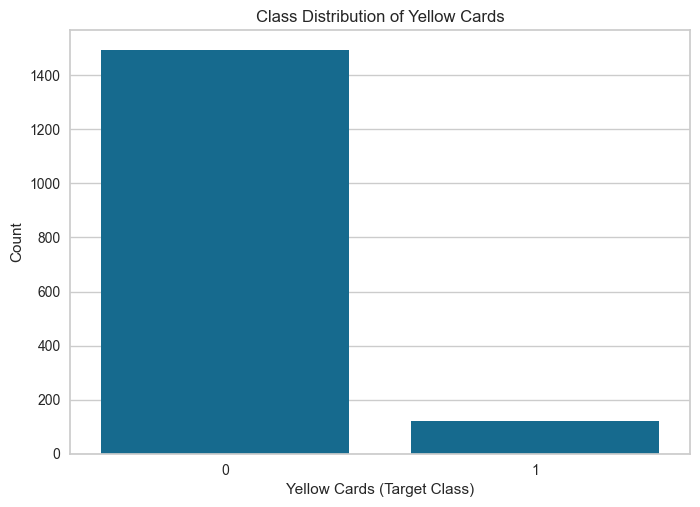

In [27]:
g_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_y_data = g_y_data[y_features]
g_y_data_tar = g_y_data_tar[y_features]

g_y_data.reset_index(drop=True, inplace=True)
g_y_data.reset_index(drop=True, inplace=True)

g_y_data.drop(columns=['position'], inplace=True)
g_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [28]:
g_y_base_model = setup(data=g_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 994, number of negative: 994
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12236
[LightGBM] [Info] Number of data points in the train set: 1988, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1612, 75)"
4,Transformed data shape,"(2472, 15)"
5,Transformed train set shape,"(1988, 15)"
6,Transformed test set shape,"(484, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [29]:
best_base_g_y = g_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9167,0.5173,0.0236,0.0750,0.0348,0.0156,0.0143,2.1760
xgboost,Extreme Gradient Boosting,0.9105,0.5130,0.0361,0.1833,0.0582,0.0298,0.0458,9.4060
lightgbm,Light Gradient Boosting Machine,0.9193,0.5110,0.0236,0.0667,0.0348,0.0203,0.0204,3.6680
qda,Quadratic Discriminant Analysis,0.7128,0.5082,0.2958,0.0855,0.1306,0.0190,0.0247,1.9970
dt,Decision Tree Classifier,0.8227,0.5038,0.1292,0.0718,0.0909,0.0018,0.0025,1.9690
rf,Random Forest Classifier,0.9140,0.5025,0.0000,0.0000,0.0000,-0.0185,-0.0247,2.8990
svm,SVM - Linear Kernel,0.4980,0.5004,0.4403,0.0662,0.1144,-0.0159,-0.0307,2.4880
dummy,Dummy Classifier,0.9255,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,2.2290
knn,K Neighbors Classifier,0.5913,0.4921,0.3931,0.0737,0.1241,-0.0012,-0.0005,1.1330
et,Extra Trees Classifier,0.9131,0.4766,0.0000,0.0000,0.0000,-0.0201,-0.0260,16.6140


In [ ]:
evaluate_model(best_base_g_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [31]:
tune_model_gk_y = tune_model(best_base_g_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8938,0.4560,0.0000,0.0000,0.0000,-0.0495,-0.0529
1,0.8938,0.5143,0.0000,0.0000,0.0000,-0.0495,-0.0529
2,0.9204,0.5536,0.0000,0.0000,0.0000,-0.0160,-0.0261
3,0.9115,0.5095,0.0000,0.0000,0.0000,-0.0291,-0.0371
4,0.8850,0.5427,0.0000,0.0000,0.0000,-0.0515,-0.0564
5,0.9115,0.6378,0.0000,0.0000,0.0000,-0.0162,-0.0278
6,0.8938,0.5107,0.1111,0.2000,0.1429,0.0912,0.0956
7,0.8850,0.4402,0.0000,0.0000,0.0000,-0.0515,-0.0564
8,0.9018,0.4038,0.1250,0.2000,0.1538,0.1047,0.1079


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [32]:
final_best_base_g_y = finalize_model(best_base_g_y)
save_model(final_best_base_g_y, './models/gk_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                             criterion='friedman_mse', init=None,
                    

## DEF


yellow_cards
0    5581
1     992
Name: count, dtype: int64


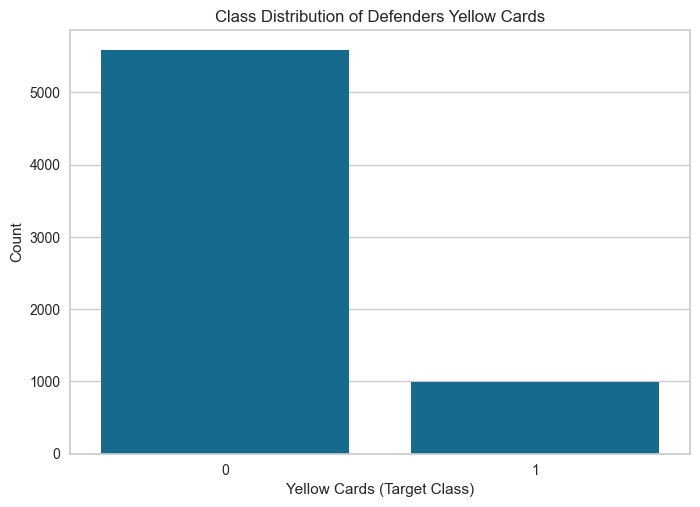

In [33]:
def_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_y_data = def_y_data[y_features]
def_y_data_tar = def_y_data_tar[y_features]

def_y_data.reset_index(drop=True, inplace=True)
def_y_data.reset_index(drop=True, inplace=True)

def_y_data.drop(columns=['position'], inplace=True)
def_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(def_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=def_y_data)
plt.title('Class Distribution of Defenders Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [34]:
def_y_base_model = setup(data=def_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 3713, number of negative: 3713
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.925227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15409
[LightGBM] [Info] Number of data points in the train set: 7426, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6573, 75)"
4,Transformed data shape,"(9398, 15)"
5,Transformed train set shape,"(7426, 15)"
6,Transformed test set shape,"(1972, 15)"
7,Numeric features,73
8,Rows with missing values,0.0%
9,Preprocess,True


In [35]:
best_base_def_y = def_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8344,0.5564,0.0259,0.1733,0.0439,0.0059,0.0090,5.5310
rf,Random Forest Classifier,0.8309,0.5560,0.0389,0.2077,0.0645,0.0157,0.0239,2.7470
gbc,Gradient Boosting Classifier,0.8389,0.5452,0.0245,0.1604,0.0416,0.0122,0.0179,9.4950
et,Extra Trees Classifier,0.8198,0.5429,0.0504,0.1715,0.0749,0.0091,0.0116,21.7550
xgboost,Extreme Gradient Boosting,0.8242,0.5393,0.0518,0.2039,0.0804,0.0192,0.0265,13.3130
ada,Ada Boost Classifier,0.7994,0.5359,0.0981,0.1885,0.1252,0.0270,0.0295,4.0510
lr,Logistic Regression,0.5227,0.5333,0.5245,0.1634,0.2491,0.0248,0.0337,1.9870
ridge,Ridge Classifier,0.5255,0.5326,0.5187,0.1631,0.2481,0.0241,0.0326,1.6520
lda,Linear Discriminant Analysis,0.5249,0.5313,0.5158,0.1622,0.2467,0.0224,0.0303,25.5270
nb,Naive Bayes,0.4266,0.5284,0.6541,0.1593,0.2561,0.0179,0.0296,4.8990


In [ ]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

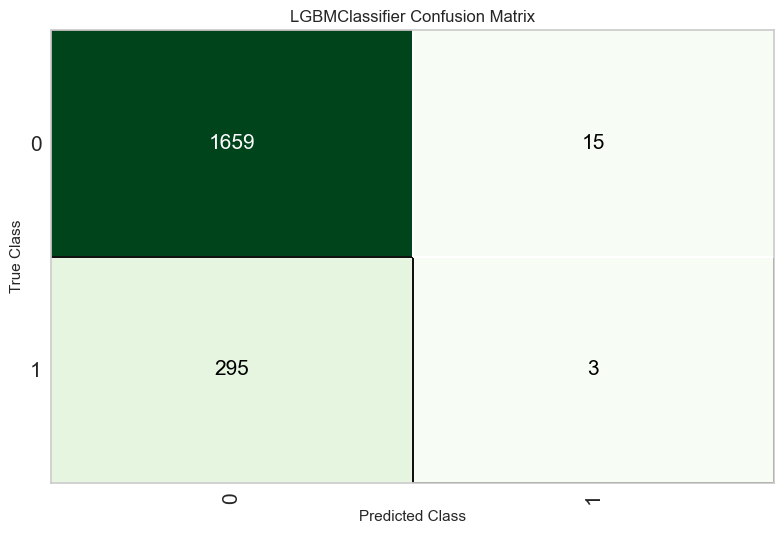

In [37]:
plot_model(best_base_def_y, plot='confusion_matrix')

### Tuned Model


In [38]:
tune_model_def_y = tune_model(best_base_def_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8286,0.6231,0.0857,0.2857,0.1319,0.0664,0.0815
1,0.8478,0.5754,0.0725,0.4545,0.1250,0.0874,0.1335
2,0.8435,0.5713,0.0290,0.2857,0.0526,0.0257,0.0472
3,0.8174,0.5102,0.0145,0.0588,0.0233,-0.0383,-0.0500
4,0.8239,0.5713,0.0435,0.1667,0.0690,0.0074,0.0094
5,0.8283,0.5476,0.0290,0.1429,0.0482,-0.0025,-0.0035
6,0.8196,0.5655,0.0580,0.1818,0.0879,0.0166,0.0200
7,0.8152,0.5179,0.0000,0.0000,0.0000,-0.0568,-0.0778
8,0.8087,0.5751,0.0000,0.0000,0.0000,-0.0664,-0.0855


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [39]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [40]:
final_best_base_def_y = finalize_model(best_base_def_y)
save_model(final_best_base_def_y, './models/def_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                            

## MID


yellow_cards
0    5970
1    1106
Name: count, dtype: int64


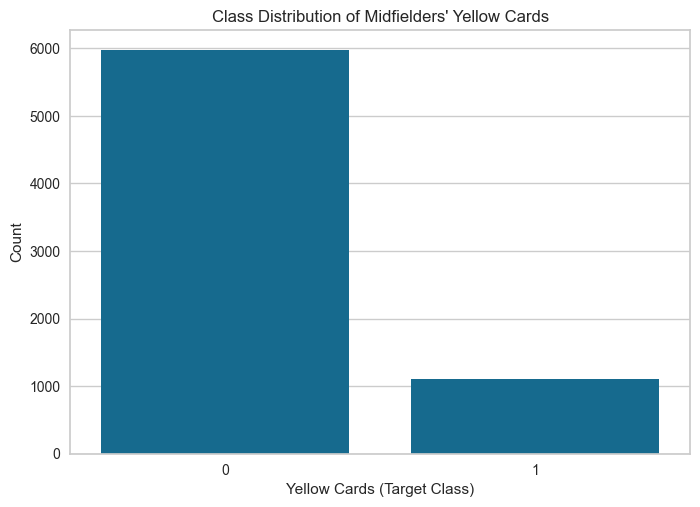

In [41]:
mid_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_y_data = mid_y_data[y_features]
mid_y_data_tar = mid_y_data_tar[y_features]

mid_y_data.reset_index(drop=True, inplace=True)
mid_y_data.reset_index(drop=True, inplace=True)

mid_y_data.drop(columns=['position'], inplace=True)
mid_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(mid_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=mid_y_data)
plt.title('Class Distribution of Midfielders\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [42]:
mid_y_base_model = setup(data=mid_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 3962, number of negative: 3962
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.867077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15521
[LightGBM] [Info] Number of data points in the train set: 7924, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(7076, 75)"
4,Transformed data shape,"(10047, 15)"
5,Transformed train set shape,"(7924, 15)"
6,Transformed test set shape,"(2123, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [43]:
best_base_mid_y = mid_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.5720,0.5894,0.5634,0.1970,0.2916,0.0783,0.1003,1.7720
lda,Linear Discriminant Analysis,0.5720,0.5894,0.5634,0.1970,0.2916,0.0783,0.1003,1.3480
lr,Logistic Regression,0.5738,0.5893,0.5570,0.1964,0.2902,0.0769,0.0981,2.5860
nb,Naive Bayes,0.4817,0.5734,0.6669,0.1824,0.2864,0.0545,0.0842,4.4180
qda,Quadratic Discriminant Analysis,0.5241,0.5723,0.5959,0.1840,0.2810,0.0556,0.0775,1.2720
gbc,Gradient Boosting Classifier,0.8367,0.5628,0.0141,0.0546,0.0185,0.0033,-0.0025,2.9870
svm,SVM - Linear Kernel,0.5459,0.5616,0.5622,0.1864,0.2776,0.0582,0.0774,5.0300
rf,Random Forest Classifier,0.8284,0.5614,0.0477,0.2387,0.0755,0.0296,0.0412,2.6860
et,Extra Trees Classifier,0.8207,0.5579,0.0658,0.2306,0.1000,0.0364,0.0449,1.7950
xgboost,Extreme Gradient Boosting,0.8137,0.5523,0.0620,0.2023,0.0930,0.0207,0.0262,1.5320


In [ ]:
evaluate_model(best_base_mid_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [45]:
tune_model_mid_y = tune_model(best_base_mid_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5867,0.6030,0.5256,0.1962,0.2857,0.0735,0.0912
1,0.6129,0.5787,0.5641,0.2178,0.3143,0.1130,0.1379
2,0.5444,0.5763,0.5641,0.1864,0.2803,0.0574,0.0764
3,0.5434,0.5389,0.4872,0.1696,0.2517,0.0234,0.0301
4,0.5515,0.6348,0.6623,0.2065,0.3148,0.1018,0.1402
5,0.5475,0.5561,0.5455,0.1818,0.2727,0.0514,0.0678
6,0.5354,0.5164,0.4675,0.1600,0.2384,0.0086,0.0112
7,0.6303,0.6574,0.6364,0.2402,0.3488,0.1587,0.1955
8,0.5939,0.5780,0.5065,0.1931,0.2796,0.0701,0.0859


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [46]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [47]:
final_best_base_mid_y = finalize_model(tune_model_mid_y)
save_model(final_best_base_mid_y, './models/mid_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          reg_alpha=0.

## FWD


yellow_cards
0    1402
1     188
Name: count, dtype: int64


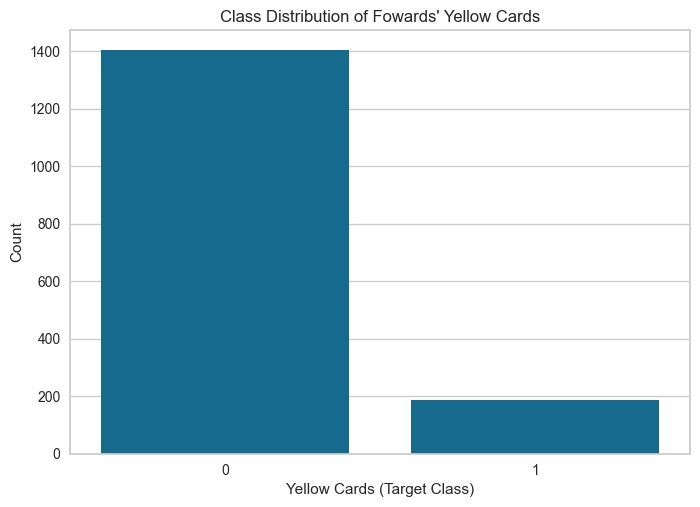

In [48]:
fwd_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_y_data = fwd_y_data[y_features]
fwd_y_data_tar = fwd_y_data_tar[y_features]

fwd_y_data.reset_index(drop=True, inplace=True)
fwd_y_data.reset_index(drop=True, inplace=True)

fwd_y_data.drop(columns=['position'], inplace=True)
fwd_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(fwd_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=fwd_y_data)
plt.title('Class Distribution of Fowards\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [49]:
fwd_y_base_model = setup(data=fwd_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 933, number of negative: 933
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002863 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14777
[LightGBM] [Info] Number of data points in the train set: 1866, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1590, 75)"
4,Transformed data shape,"(2343, 15)"
5,Transformed train set shape,"(1866, 15)"
6,Transformed test set shape,"(477, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [50]:
best_base_fwd_y = fwd_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.7557,0.5104,0.1890,0.1344,0.1555,0.0195,0.0195,0.8670
xgboost,Extreme Gradient Boosting,0.8454,0.5015,0.0000,0.0000,0.0000,-0.0564,-0.0688,0.9410
dummy,Dummy Classifier,0.8814,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,1.1580
knn,K Neighbors Classifier,0.5373,0.4977,0.4451,0.1154,0.1829,-0.0051,-0.0038,1.0370
gbc,Gradient Boosting Classifier,0.8545,0.4880,0.0225,0.0750,0.0315,-0.0172,-0.0204,1.5490
et,Extra Trees Classifier,0.8572,0.4809,0.0077,0.0200,0.0111,-0.0319,-0.0453,1.1780
nb,Naive Bayes,0.5140,0.4792,0.4319,0.1096,0.1744,-0.0181,-0.0280,1.0070
rf,Random Forest Classifier,0.8527,0.4779,0.0077,0.0333,0.0125,-0.0357,-0.0455,1.2720
lightgbm,Light Gradient Boosting Machine,0.8526,0.4750,0.0077,0.0143,0.0100,-0.0385,-0.0516,2.3510
svm,SVM - Linear Kernel,0.5382,0.4729,0.4176,0.1158,0.1802,-0.0076,-0.0170,1.0580


In [51]:
evaluate_model(best_base_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [52]:
tune_model_fwd_y = tune_model(best_base_fwd_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8750,0.4615,0.1538,0.4000,0.2222,0.1686,0.1916
1,0.7411,0.5853,0.2143,0.1429,0.1714,0.0252,0.0259
2,0.6161,0.4093,0.0714,0.0323,0.0444,-0.1544,-0.1735
3,0.8108,0.5043,0.0000,0.0000,0.0000,-0.0980,-0.1015
4,0.6847,0.2531,0.0000,0.0000,0.0000,-0.1727,-0.1811
5,0.7477,0.5824,0.1538,0.1053,0.1250,-0.0164,-0.0168
6,0.5856,0.5188,0.3077,0.0976,0.1481,-0.0361,-0.0465
7,0.8288,0.6401,0.2308,0.2500,0.2400,0.1437,0.1439
8,0.7928,0.6570,0.2308,0.1875,0.2069,0.0892,0.0898


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [53]:
evaluate_model(tune_model_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [54]:
final_best_base_fwd_y = finalize_model(tune_model_fwd_y)
save_model(final_best_base_fwd_y, './models/fwd_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                 norm_order=1,
                       